# `lci.lc.LightCurve` — 各種モード使用例

`lcbinint.lc.LightCurve` は、レンズモデルの増光率計算に特化した API です。  
構築時に物理効果（Effects）・数値オプション（Options）・リム黒化を指定し、`lc(times, **params)` で増光率を返します。

## 本ノートブックで扱うモード

| セクション | 主要パラメータ |
|-----------|---------------|
| 1. 基本バイナリレンズ (点源) | t0, tE, u0, s, q, alpha |
| 2. 有限源・リム黒化 | + rho, ld_c |
| 3. 視差 (parallax) | + piEN, piEE, sky, t_ref |
| 4. レンズ軌道運動 (lom circular/kepler) | + g1, g2, g3 [, lom_szs, lom_ar] |
| 5. xallarap 4 モード | + xi_1, xi_2, ... |
| 6. バイナリ源 (独立) | + q_source, t0_2, u0_2 |
| 7. バイナリ源 + xallarap (coupled) | + q_source, q_mass |


In [1]:
import sys
from pathlib import Path

# ローカルビルドを優先（build → build_new の順で探す）
for build_dir in ("build", "build_new"):
    p = next(
        (r / build_dir for r in (Path.cwd(), *Path.cwd().parents) if (r / build_dir).is_dir()),
        None,
    )
    if p is not None:
        sys.path.insert(0, str(p))
        break

import numpy as np
import matplotlib.pyplot as plt
import lcbinint as lci

print("lcbinint loaded from:", lci.__file__)

lcbinint loaded from: /rogue1_8/nunota/lcbinint/build/lcbinint/__init__.py


## 1. 基本バイナリレンズ（点源）

`LightCurve()` はデフォルトで `param_type='vbm'`（VBM 互換座標系）の点源二重レンズ。

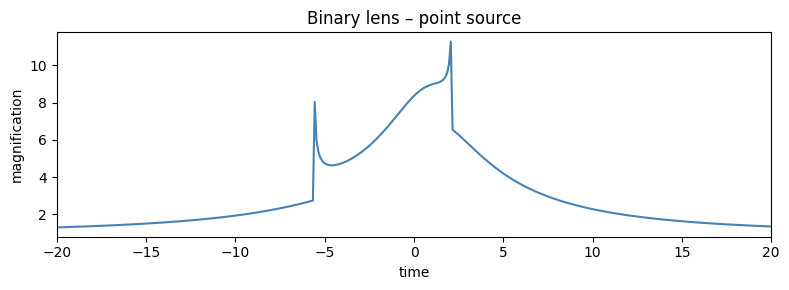

<lc.LightCurve param_type='vbm' source_bins=50>


In [2]:
t = np.linspace(-20, 20, 400)

lc_basic = lci.lc.LightCurve()

params_basic = dict(t0=0.0, tE=20.0, u0=0.1, s=1.1, q=0.05, alpha=0.8)
mag_basic = lc_basic(t, **params_basic)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t, mag_basic, lw=1.5, color="steelblue")
ax.set(xlabel="time", ylabel="magnification", title="Binary lens – point source")
ax.set_xlim(t[0], t[-1])
plt.tight_layout()
plt.show()

print(lc_basic)

## 2. 有限源・リム黒化

`rho` で有限源サイズを指定。`LightCurve(ld_c=...)` で線形リム黒化を有効化。

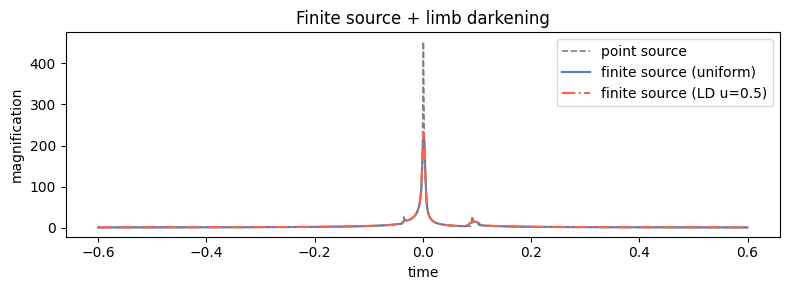

In [3]:
lc_ps  = lci.lc.LightCurve()
lc_fs  = lci.lc.LightCurve()
lc_ld  = lci.lc.LightCurve(ld_c=0.5)  # linear limb darkening u=0.5

# カウスティック横断が見えるパラメータ
t_fs = np.linspace(-0.6, 0.6, 600)
p_fs = dict(t0=0.0, tE=0.5, u0=-0.005, s=0.95, q=0.01, alpha=0.5, rho=5e-3)

mag_ps = lc_ps(t_fs, **{**p_fs, 'rho': 0.0})  # rho=0 → 点源
mag_fs = lc_fs(t_fs, **p_fs)
mag_ld = lc_ld(t_fs, **p_fs)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_fs, mag_ps, label="point source",           lw=1.2, ls="--", color="gray")
ax.plot(t_fs, mag_fs, label="finite source (uniform)", lw=1.5, color="steelblue")
ax.plot(t_fs, mag_ld, label="finite source (LD u=0.5)",lw=1.5, color="tomato", ls="-.")
ax.set(xlabel="time", ylabel="magnification", title="Finite source + limb darkening")
ax.legend()
plt.tight_layout()
plt.show()

## 3. 視差（Parallax）

`parallax=True` を指定する場合、天空座標 `sky` と基準時刻 `t_ref` が必要。  
パラメータには `piEN`, `piEE`（Einstein ring 単位の視差ベクトル）を追加。

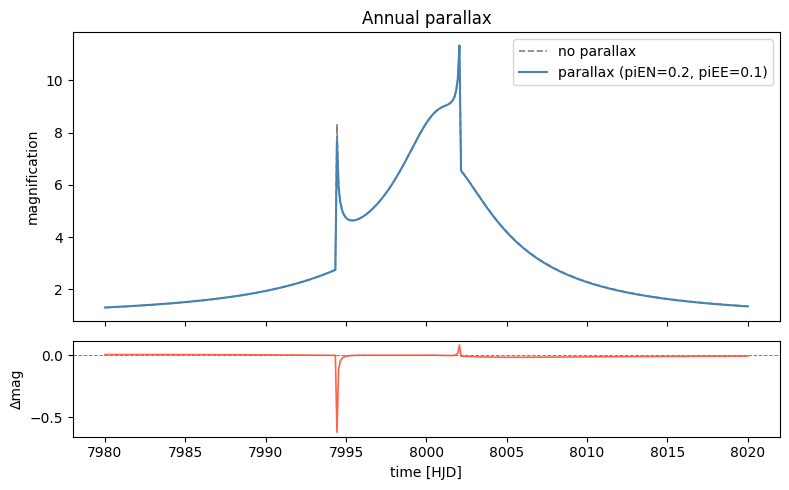

<lc.LightCurve param_type='vbm' source_bins=50>


In [4]:
sky = lci.obs.SkyCoord(ra=270.0, dec=-30.0)  # degrees
t0_ref = 8000.0
t_par = np.linspace(t0_ref - 20, t0_ref + 20, 400)

lc_nopar = lci.lc.LightCurve()
lc_par   = lci.lc.LightCurve(parallax=True, sky=sky, t_ref=t0_ref)

p_par = dict(t0=t0_ref, tE=20.0, u0=0.1, s=1.1, q=0.05, alpha=0.8, piEN=0.2, piEE=0.1)

mag_nopar = lc_nopar(t_par, **p_par)
mag_par   = lc_par  (t_par, **p_par)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})
ax1.plot(t_par, mag_nopar, label="no parallax", lw=1.2, ls="--", color="gray")
ax1.plot(t_par, mag_par,   label="parallax (piEN=0.2, piEE=0.1)", lw=1.5, color="steelblue")
ax1.set_ylabel("magnification")
ax1.set_title("Annual parallax")
ax1.legend()
ax2.plot(t_par, mag_par - mag_nopar, color="tomato", lw=1.2)
ax2.set(xlabel="time [HJD]", ylabel="Δmag")
ax2.axhline(0, color="gray", lw=0.7, ls="--")
plt.tight_layout()
plt.show()

print(lc_par)

## 4. レンズ軌道運動（Lens Orbital Motion）

レンズ連星の相対運動。`orbital_motion='circular'` または `'kepler'` を指定。  
`t_ref` が必要（円軌道・ケプラー共通）。

| パラメータ | 意味 |
|-----------|------|
| g1 | ds/dt / s |
| g2 | dα/dt [rad/day] |
| g3 | ds_z/dt / s（視線方向成分） |
| lom_szs | s_z / s（tref での視線/射影比）← kepler のみ |
| lom_ar | a/s（軌道長半径/射影距離比）← kepler のみ |

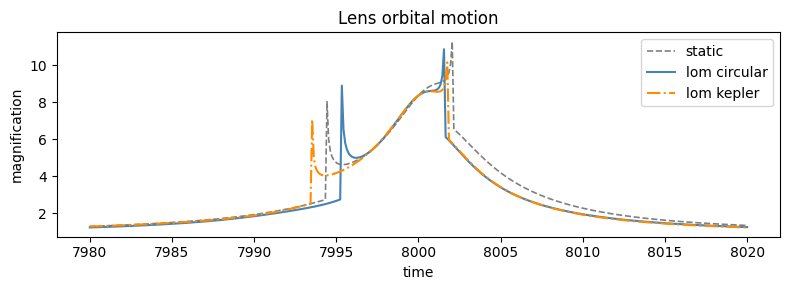

In [5]:
t_lom = np.linspace(t0_ref - 20, t0_ref + 20, 400)

lc_static   = lci.lc.LightCurve()
lc_circ_lom = lci.lc.LightCurve(orbital_motion='circular', t_ref=t0_ref)
lc_kepl_lom = lci.lc.LightCurve(orbital_motion='kepler',   t_ref=t0_ref)

p_lom_base = dict(t0=t0_ref, tE=20.0, u0=0.1, s=1.1, q=0.05, alpha=0.8)
lom_extra = dict(g1=0.01, g2=0.15, g3=0.0)  # gentle rotation

mag_static   = lc_static  (t_lom, **p_lom_base)
mag_circ_lom = lc_circ_lom(t_lom, **p_lom_base, **lom_extra)
mag_kepl_lom = lc_kepl_lom(t_lom, **p_lom_base, **lom_extra, lom_szs=0.05, lom_ar=2.5)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_lom, mag_static,   label="static",        lw=1.2, ls="--", color="gray")
ax.plot(t_lom, mag_circ_lom, label="lom circular",  lw=1.5, color="steelblue")
ax.plot(t_lom, mag_kepl_lom, label="lom kepler",    lw=1.5, color="darkorange", ls="-.")
ax.set(xlabel="time", ylabel="magnification", title="Lens orbital motion")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Xallarap（源の軌道運動）— 4 モード

xallarap は source star の軌道運動。パラメータ化方法で 4 種類のモードがある。

### モード一覧

| モード | 分類 | パラメータ |
|--------|------|----------|
| `orbital_elements` | 軌道要素 × Kepler | xi_1, xi_2, period_xa, ecc_xa, peri_xa, inc_xa |
| `circular_elements` | 軌道要素 × 円軌道 | xi_1, xi_2, period_xa, inc_xa |
| `circular_velocity` | 位置速度 × 円軌道 | xi_1, xi_2, w1, w2, w3 |
| `kepler_velocity` | 位置速度 × Kepler | xi_1, xi_2, w1, w2, w3, xa_szs, xa_ar |

**elements 系**: `(t0, u0)` が CoM に対応。`xi_1/xi_2` は振幅＋方向。  
**velocity 系**: `(t0, u0)` が CoM。`xi_1/xi_2` は tref でのソース位置。

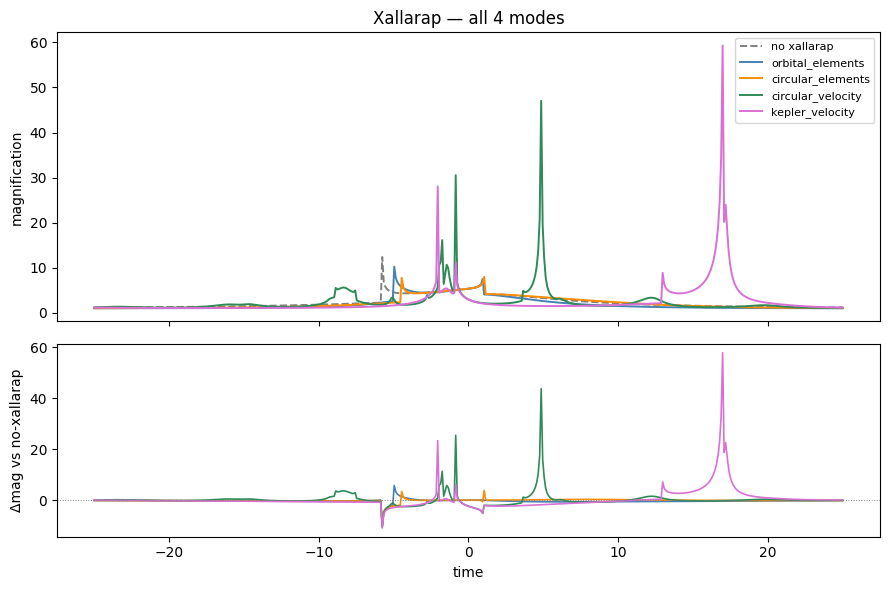

In [6]:
t_xa = np.linspace(-25, 25, 500)

p_base = dict(t0=0.0, tE=20.0, u0=0.2, s=1.1, q=0.05, alpha=0.8)

modes = [
    ("no xallarap", lci.lc.LightCurve(), {}),
    ("orbital_elements",
     lci.lc.LightCurve(xallarap="orbital_elements"),
     dict(xi_1=0.3, xi_2=0.0, period_xa=40.0, ecc_xa=0.3, peri_xa=0.8, inc_xa=1.0)),
    ("circular_elements",
     lci.lc.LightCurve(xallarap="circular_elements"),
     dict(xi_1=0.3, xi_2=0.0, period_xa=40.0, inc_xa=1.0)),
    ("circular_velocity",
     lci.lc.LightCurve(xallarap="circular_velocity"),
     dict(xi_1=0.3, xi_2=0.0, w1=0.01, w2=0.8, w3=0.1)),
    ("kepler_velocity",
     lci.lc.LightCurve(xallarap="kepler_velocity"),
     dict(xi_1=0.3, xi_2=0.0, w1=0.01, w2=0.8, w3=0.1, xa_szs=0.1, xa_ar=2.0)),
]

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True,
                         gridspec_kw={'height_ratios': [3, 2]})

colors = ["gray", "steelblue", "darkorange", "seagreen", "orchid"]
mags = {}
for (label, lc_xa, extra), color in zip(modes, colors):
    m = lc_xa(t_xa, **p_base, **extra)
    mags[label] = m
    ls = "--" if label == "no xallarap" else "-"
    axes[0].plot(t_xa, m, label=label, lw=1.4, ls=ls, color=color)

m0 = mags["no xallarap"]
for (label, _, _), color in zip(modes[1:], colors[1:]):
    axes[1].plot(t_xa, mags[label] - m0, label=label, lw=1.2, color=color)

axes[0].set_ylabel("magnification")
axes[0].set_title("Xallarap — all 4 modes")
axes[0].legend(fontsize=8)
axes[1].set_ylabel("Δmag vs no-xallarap")
axes[1].set_xlabel("time")
axes[1].axhline(0, color="gray", lw=0.7, ls=":")
plt.tight_layout()
plt.show()

### 5a. orbital_elements(ecc=0, peri=0) ≡ circular_elements の確認

In [7]:
lc_oe = lci.lc.LightCurve(xallarap="orbital_elements")
lc_ce = lci.lc.LightCurve(xallarap="circular_elements")

kw = dict(xi_1=0.3, xi_2=0.0, period_xa=40.0, inc_xa=1.0)
m_oe = lc_oe(t_xa, **p_base, **kw, ecc_xa=0.0, peri_xa=0.0)
m_ce = lc_ce(t_xa, **p_base, **kw)

print("max |orbital_elements(ecc=0) - circular_elements|:",
      np.max(np.abs(m_oe - m_ce)))

max |orbital_elements(ecc=0) - circular_elements|: 0.0


## 6. バイナリ源（Binary Source）— 独立パラメータ

`source='binary'` で二つの点源の重みつき合計を計算。  
Source 2 は独自の軌跡を持つ（`t0_2`, `u0_2`）。

$$A_{\rm eff} = \frac{A_1 + q_{\rm source} A_2}{1 + q_{\rm source}}$$

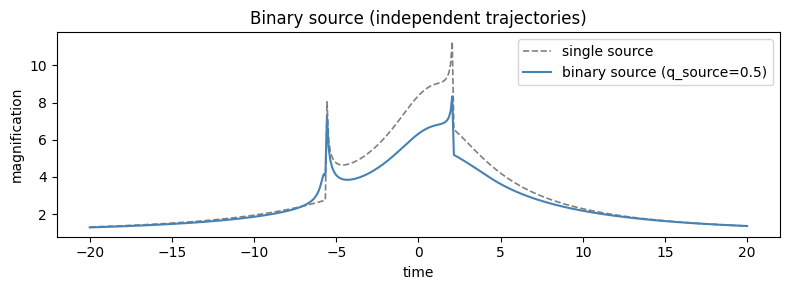

In [8]:
t_bs = np.linspace(-20, 20, 400)

lc_single = lci.lc.LightCurve()
lc_binary = lci.lc.LightCurve(source='binary')

p_single = dict(t0=0.0, tE=20.0, u0=0.1, s=1.1, q=0.05, alpha=0.8)

mag_single = lc_single(t_bs, **p_single)
# Source 2: 少しずれた軌跡
mag_binary = lc_binary(t_bs, **p_single, q_source=0.5, t0_2=2.0, u0_2=0.4)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_bs, mag_single, label="single source",                lw=1.2, ls="--", color="gray")
ax.plot(t_bs, mag_binary, label="binary source (q_source=0.5)", lw=1.5, color="steelblue")
ax.set(xlabel="time", ylabel="magnification", title="Binary source (independent trajectories)")
ax.legend()
plt.tight_layout()
plt.show()

## 7. バイナリ源 + Xallarap（Coupled）

`q_mass` を指定すると、source 1 の xallarap に対して source 2 の xi が自動計算される：

$$\xi_{1,2} = -\xi_1 / q_{\rm mass}, \quad \xi_{2,2} = -\xi_2 / q_{\rm mass}$$

軌道形状パラメータ（period_xa, inc_xa など）は両ソースで共有。

coupled vs manual max diff: 0.0


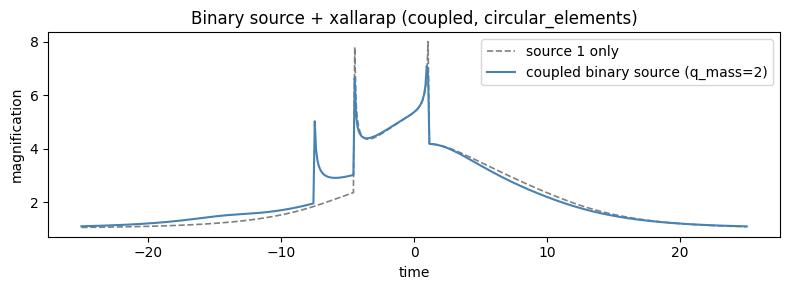

In [9]:
t_coupled = np.linspace(-25, 25, 500)

lc_s  = lci.lc.LightCurve(xallarap='circular_elements')
lc_coupled = lci.lc.LightCurve(xallarap='circular_elements', source='binary')

p_xa = dict(t0=0.0, tE=20.0, u0=0.2, s=1.1, q=0.05, alpha=0.8,
            xi_1=0.3, xi_2=0.0, period_xa=40.0, inc_xa=1.0)

q_mass   = 2.0
q_source = 1.0 / q_mass  # mass ratio ≒ flux ratio (同種の星を想定)

mag_s1      = lc_s(t_coupled, **p_xa)
mag_coupled = lc_coupled(t_coupled, **p_xa, q_source=q_source, q_mass=q_mass)

# 手動検証: source2 の xi は -xi/q_mass
p_xa2 = {**p_xa, 'xi_1': -p_xa['xi_1'] / q_mass, 'xi_2': -p_xa['xi_2'] / q_mass}
mag_s2 = lc_s(t_coupled, **p_xa2)
mag_manual = (mag_s1 + q_source * mag_s2) / (1 + q_source)

print("coupled vs manual max diff:", np.max(np.abs(mag_coupled - mag_manual)))

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_coupled, mag_s1,      label="source 1 only",                 lw=1.2, ls="--", color="gray")
ax.plot(t_coupled, mag_coupled, label="coupled binary source (q_mass=2)", lw=1.5, color="steelblue")
ax.set(xlabel="time", ylabel="magnification",
       title="Binary source + xallarap (coupled, circular_elements)")
ax.legend()
plt.tight_layout()
plt.show()

## まとめ

`lci.lc.LightCurve` の主要引数:

```python
lci.lc.LightCurve(
    # 物理効果
    source='single',           # 'single' | 'binary'
    orbital_motion='static',   # 'static' | 'circular' | 'kepler'  (+t_ref 必要)
    xallarap='none',           # 'none' | 'orbital_elements' | 'circular_elements'
                               #        | 'circular_velocity' | 'kepler_velocity'
    parallax=False,            # True (+sky, t_ref 必要)
    sky=lci.obs.SkyCoord(ra, dec),
    t_ref=...,
    # リム黒化
    ld_c=0.0,                  # 線形係数
    ld_d=0.0,                  # 平方根係数
    # 数値オプション
    source_bins=50,
    param_type='vbm',          # 'vbm' | 'lcbinint' | 'center_of_mass'
)
```

構築後は `lc(times, **params)` で numpy 配列を返す。